In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_arabica = pd.read_csv('../data/raw/arabica_data_cleaned.csv')
df_robusta = pd.read_csv('../data/raw/robusta_data_cleaned.csv')

In [3]:
## Adding an extra species column
df_arabica['Species'] = 'Arabica'
df_robusta['Species'] = 'Robusta'

In [4]:
## Stack them together
df_quality = pd.concat([df_arabica, df_robusta], ignore_index=True)
print(f"Combined dataset has {df_quality.shape[0]} coffee reviews.")

Combined dataset has 1339 coffee reviews.


In [8]:
### Now we extract just the sensory metrics (Aroma, Flavour, etc.) and calculate the average score for each country.
### Notice we are using 'Country of Origin' with spaces, based on our earlier debugging.

# The exact columns we need for our dash radar chart
quality_cols = ['Country.of.Origin', 'Aroma', 'Flavor', 'Acidity', 'Body', 'Balance']

#Filter, drop rows with missing data, and group by country
df_bean_raw = df_quality[quality_cols].dropna()
df_bean = df_bean_raw.groupby('Country.of.Origin').mean().reset_index()


In [9]:
print("\nAggregated Bean Profiles (First 5):")
display(df_bean.head())


Aggregated Bean Profiles (First 5):


,Country.of.Origin,Aroma,Flavor,Acidity,Body,Balance
0,Brazil,7.553106,7.573561,7.511439,7.544545,7.531515
1,Burundi,7.415000,7.460000,7.415000,7.290000,7.415000
2,China,7.641250,7.625625,7.578125,7.573750,7.548125
3,Colombia,7.653060,7.597104,7.560000,7.609508,7.708415
4,Costa Rica,7.671373,7.537255,7.573922,7.537451,7.637255


In [10]:
df_bean = df_bean.rename(columns={'Country.of.Origin':'Country of Origin'})

In [11]:
display(df_bean.head())

,Country of Origin,Aroma,Flavor,Acidity,Body,Balance
0,Brazil,7.553106,7.573561,7.511439,7.544545,7.531515
1,Burundi,7.415000,7.460000,7.415000,7.290000,7.415000
2,China,7.641250,7.625625,7.578125,7.573750,7.548125
3,Colombia,7.653060,7.597104,7.560000,7.609508,7.708415
4,Costa Rica,7.671373,7.537255,7.573922,7.537451,7.637255


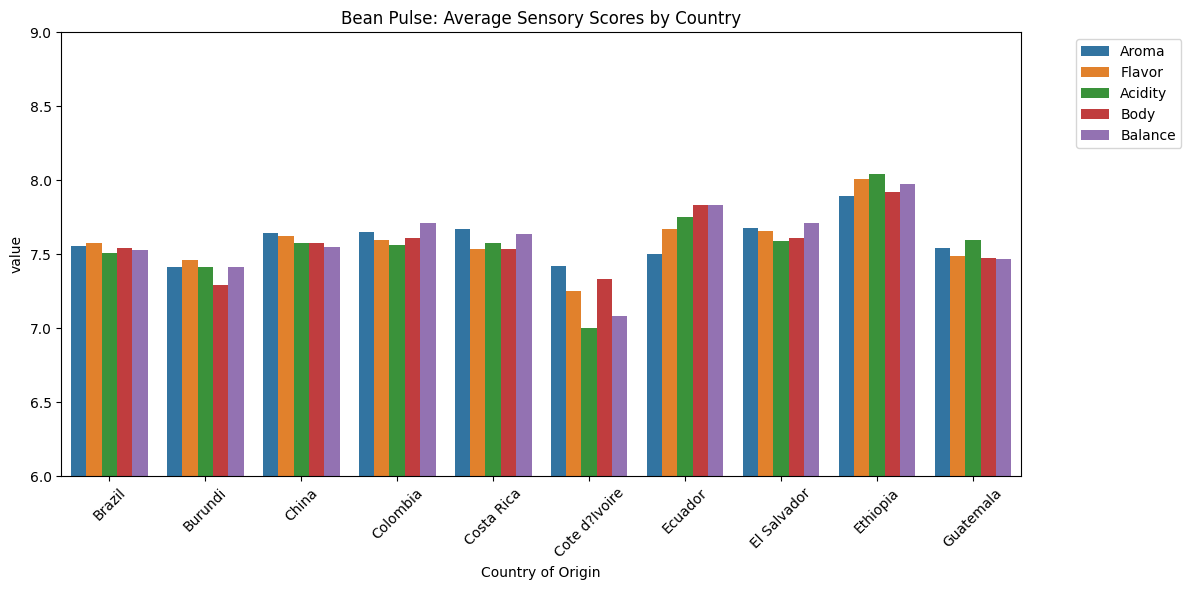

In [ ]:
# to see the data, we will plot a clustered bar chart. We use 'pd.melt()' to reshape the data so seaborn can easily plot all five metrics side-by-side for each country

# grab 10 countries just to keep the chart readable
top_10 = df_bean.head(10)

plt.figure(figsize=(12,6))

# 'melt' turns our columns into rows, making it perfect for bar charts
sns.barplot(data=top_10.melt(id_vars='Country of Origin'), x='Country of Origin', y='value', hue='variable')
plt.title("Bean Pulse: Average Sensory Scores by Country")
plt.xticks(rotation=45)

# Coffee Cupping scores almost always fall between 6 and 9
plt.ylim(6, 9) 

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
# save this clean csv, aggregated table so your dash app can load it instantly.
df_bean.to_csv('../data/processed/bean_profile.csv', index=False)